# PASO 4 — Modelado Predictivo
## Proyecto: Análisis de Churn en TELCO

**Equipo:** Data & BI

**Objetivo de esta fase:** construir, evaluar y comparar tres modelos de
clasificación para predecir el churn, y aplicar el mejor modelo sobre los
**clientes activos** para obtener su probabilidad estimada de abandono.

El flujo de trabajo es:

1. **Eliminación de data leakage** — quitar variables que "filtran" el futuro.
2. **Separación train / test** — división estratificada 80/20.
3. **Preprocesamiento** — pipeline de sklearn (imputación + OHE).
4. **Entrenamiento y evaluación** — Regresión Logística, Random Forest y
   Gradient Boosting.
5. **Selección del modelo** — comparativa de métricas y elección justificada.
6. **Importancia de variables** — RF y GB, comparadas con el PASO 3.
7. **Predicción sobre clientes activos** — exportar `test_predictions.csv`.

Todas las figuras se guardan en `docs/modelado_predictivo/`.
**Entregable:** `data/processed/test_predictions.csv`

## 0. Configuración inicial

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                              roc_auc_score, roc_curve, ConfusionMatrixDisplay)

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
sns.set_theme(style='whitegrid')

CLEANED_PATH  = '../data/cleaned/telco_cleaned.csv'
PROCESSED_PATH = '../data/processed/'
OUT_DIR       = '../docs/modelado_predictivo/'
os.makedirs(PROCESSED_PATH, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

df = pd.read_csv(CLEANED_PATH)
print("Shape:", df.shape)
print(f"Tasa de churn global: {df['churn_value'].mean():.2%}")

Shape: (7043, 48)
Tasa de churn global: 26.54%


## 1. Eliminación de data leakage

Antes de entrenar cualquier modelo hay que eliminar las variables que **"filtran"
información del futuro** o que son consecuencia directa del churn ya ocurrido.
Incluirlas generaría métricas artificialmente perfectas, pero el modelo sería
inútil en producción (donde estas columnas no existen para un cliente activo).

### Variables eliminadas y por qué

| Tipo | Columnas | Motivo |
|---|---|---|
| **Leakage directo (post-churn)** | `customer_status`, `churn_label`, `churn_category`, `churn_reason` | Son consecuencia del churn ya ocurrido. `churn_category` y `churn_reason` tienen Cramér's V = 1.00 con el target (PASO 3). |
| **Identificadores** | `customer_id`, `zip_code`, `city`, `fecha_alta`, `latitude`, `longitude` | No son variables predictoras — son claves o coordenadas. Latitude/longitude además tienen VIF extremo y correlación nula con el churn (PASO 3). |
| **Redundantes** | `antiguedad_anios`, `total_revenue` | `antiguedad_anios = tenure_in_months / 12` (correlación 1.00); `total_revenue` es combinación lineal exacta de otras 4 variables (VIF = ∞). Ambas identificadas en el PASO 3. |

### ¿Cómo distinguir leakage de una buena predictora?

La prueba clave es el **"momento en el tiempo"**: ¿sabríamos el valor de esta
variable **antes** de que el cliente se fuera, en el momento real de la predicción?

- `churn_reason = 'Competitor had better devices'` → solo lo sabemos **después**
  de que el cliente ya llamó para cancelar. **Leakage.**
- `contract = 'Month-to-Month'` → lo sabemos perfectamente para cualquier cliente
  activo, en cualquier momento. **Predictora legítima.**

La otra señal de alarma es cuantitativa: Cramér's V = 1.00 o correlación de
Pearson ≈ ±1 casi nunca ocurre de forma legítima en datos reales.

In [21]:
# Columnas a excluir del modelo
LEAKAGE   = ['customer_status', 'churn_label', 'churn_category', 'churn_reason']
IDS       = ['customer_id', 'zip_code', 'fecha_alta', 'city', 'latitude', 'longitude']
REDUNDANT = ['antiguedad_anios', 'total_revenue']
TARGET    = 'churn_value'

# [TARGET] va entre corchetes porque es una lista de un solo elemento, para poder concatenarla con las otras listas
DROP_COLS    = LEAKAGE + IDS + REDUNDANT + [TARGET]
FEATURE_COLS = [c for c in df.columns if c not in DROP_COLS]

# np.number para columnas numéricas y el resto para categóricas
NUM_COLS = list(df[FEATURE_COLS].select_dtypes(include=[np.number]).columns)
CAT_COLS = list(df[FEATURE_COLS].select_dtypes(exclude=[np.number]).columns)

print(f"Features (columnas) totales: {len(FEATURE_COLS)}")
print(f"  · Numéricas ({len(NUM_COLS)}): {NUM_COLS}") # Las 12 columnas del VIF
print(f"\n  · Categóricas ({len(CAT_COLS)}):") # Variables predictoras de Cramer's V
for c in CAT_COLS:
    print(f"      {c} ({df[c].nunique()} valores únicos)")

Features (columnas) totales: 35
  · Numéricas (12): ['age', 'number_of_dependents', 'number_of_referrals', 'tenure_in_months', 'avg_monthly_long_distance_charges', 'avg_monthly_gb_download', 'monthly_charge', 'total_charges', 'total_refunds', 'total_extra_data_charges', 'total_long_distance_charges', 'population']

  · Categóricas (23):
      gender (2 valores únicos)
      under_30 (2 valores únicos)
      senior_citizen (2 valores únicos)
      married (2 valores únicos)
      dependents (2 valores únicos)
      referred_a_friend (2 valores únicos)
      offer (6 valores únicos)
      phone_service (2 valores únicos)
      multiple_lines (2 valores únicos)
      internet_service (2 valores únicos)
      internet_type (4 valores únicos)
      online_security (2 valores únicos)
      online_backup (2 valores únicos)
      device_protection_plan (2 valores únicos)
      premium_tech_support (2 valores únicos)
      streaming_tv (2 valores únicos)
      streaming_movies (2 valores únicos

## 2. Separación train / test

### Proporción elegida: 80% train — 20% test

Es la división más habitual y razonable para un dataset de este tamaño (~7.043
filas). Con un 20% de test obtenemos ~1.409 observaciones — suficientes para
estimar las métricas con confianza estadística — y dejamos el 80% para que el
modelo aprenda los patrones.

### ¿Por qué estratificar?

La estratificación (`stratify=y`) garantiza que la **proporción de churners sea
la misma en train y en test** (~26,5% en ambos). Esto es crítico aquí porque el
dataset está **desbalanceado** (≈1 churner por cada 3,8 no-churners): sin
estratificar, por azar podría quedar un test con muchos más o muchos menos
churners de lo esperado, haciendo que las métricas de test sean poco
representativas de la distribución real del negocio.

In [3]:
X = df[FEATURE_COLS]
y = df[TARGET]

X_train, X_test, y_train, y_test, id_train, id_test = train_test_split(
    X, y, df['customer_id'],
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train: {X_train.shape[0]:>5} filas | Churn rate: {y_train.mean():.2%}")
print(f"Test:  {X_test.shape[0]:>5} filas | Churn rate: {y_test.mean():.2%}")
print(f"\n→ La tasa de churn es idéntica en train ({y_train.mean():.2%})"
      f" y test ({y_test.mean():.2%}) — estratificación correcta.")

Train:  5634 filas | Churn rate: 26.54%
Test:   1409 filas | Churn rate: 26.54%

→ La tasa de churn es idéntica en train (26.54%) y test (26.54%) — estratificación correcta.


## 3. Preprocesamiento — pipeline de sklearn

Construimos un pipeline de preprocesamiento con `sklearn` que se **ajusta (fit)
únicamente sobre los datos de entrenamiento** y luego se aplica (transform) tanto
a train como a test. Si ajustáramos sobre todo el dataset, introduciríamos
**data leakage implícito** (el modelo "vería" información de las observaciones de
test durante el entrenamiento, aunque fuera solo para calcular la media/moda).

### ¿Media o mediana para variables numéricas?

Elegimos **mediana**: es más robusta frente a outliers que la media. En nuestro
dataset hay valores extremos en variables como `total_charges` o
`monthly_charge` (detectados en el PASO 1), y la mediana no se ve distorsionada
por ellos. Además, como el PASO 2 eliminó todos los nulos, el imputer numérico
no tendrá nada que imputar en `telco_cleaned.csv` — es una red de seguridad para
datos futuros.

### Variables categóricas: SimpleImputer (moda) + OneHotEncoding

Imputamos con la **moda** (valor más frecuente) — aunque, igual que con los
numéricos, no hay nulos que imputar en el dataset actual. El **OneHotEncoding**
convierte cada variable categórica en columnas binarias, necesario para que los
algoritmos (especialmente la Regresión Logística) puedan trabajar con ellas.
Usamos `handle_unknown='ignore'` para que, si en producción llega un valor de
categoría nuevo, no se rompa el pipeline — simplemente se codifica como todo
ceros.

In [4]:
# Transformador numerico: imputa medianas
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median'))
])

# Transformador categorico: imputa moda + OneHot
categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

# ColumnTransformer aplica cada transformer a sus columnas
preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, NUM_COLS),
    ('cat', categorical_transformer, CAT_COLS)
])

# Verificar dimensiones del espacio transformado (fit solo sobre train)
X_train_proc = preprocessor.fit_transform(X_train)
X_test_proc  = preprocessor.transform(X_test)

# Nombres de features tras OHE (para importancia de variables)
print(f"Dimensiones train procesado: {X_train_proc.shape}")
print(f"Dimensiones test procesado:  {X_test_proc.shape}")
# Numero de features tras OHE
raw_names = preprocessor.get_feature_names_out()
clean_names = [n.replace('num__','').replace('cat__','') for n in raw_names]
print(f"\nTotal features tras OHE: {len(clean_names)} ({len(NUM_COLS)} numéricas + {len(clean_names)-len(NUM_COLS)} columnas OHE)")

Dimensiones train procesado: (5634, 68)
Dimensiones test procesado:  (1409, 68)

Total features tras OHE: 68 (12 numéricas + 56 columnas OHE)


## 4. Los tres modelos a comparar

Entrenamos y evaluamos:

1. **Regresión Logística** — modelo lineal, interpretable, rápido. Sirve como
   **línea base**. Usamos `class_weight='balanced'` para compensar el desbalance de
   clases y `max_iter=1000` para garantizar convergencia.

2. **Random Forest** — ensamble de 200 árboles de decisión entrenados de forma
   independiente sobre submuestras aleatorias. Robusto a multicolinealidad y
   outliers. También con `class_weight='balanced'`.

3. **Gradient Boosting** — ensamble de 200 árboles entrenados de forma
   **secuencial**: cada árbol aprende a corregir los errores del anterior.
   Habitualmente el más preciso de los tres.

### Métricas de evaluación

Para cada modelo analizamos:

- **Precisión (Precision)** — de los que predecimos como churn, ¿cuántos
  realmente lo son? Relevante para no "molestar" innecesariamente a clientes que
  no van a marcharse.
- **Recall (Sensibilidad)** — de los que realmente hacen churn, ¿cuántos
  detectamos? En churn, **el recall es la métrica más importante**: un falso
  negativo (cliente que se va y no detectamos) es mucho más costoso que un falso
  positivo (cliente que retenemos innecesariamente con una oferta).
- **F1-Score** — media armónica entre precisión y recall.
- **ROC-AUC** — capacidad global del modelo para discriminar entre clases,
  independiente del umbral de clasificación.
- **Matriz de confusión** — detalle de verdaderos/falsos positivos/negativos.

In [5]:
# ── Helper: construye un pipeline fresco para cada modelo ───────────
def build_pipeline(clf):
    num_t = Pipeline(steps=[('imputer', SimpleImputer(strategy='median'))])
    cat_t = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    pre = ColumnTransformer(transformers=[
        ('num', num_t, NUM_COLS),
        ('cat', cat_t, CAT_COLS)
    ])
    return Pipeline(steps=[('preprocessor', pre), ('classifier', clf)])

# ── Definicion de los tres modelos ──────────────────────────────────
MODELOS = {
    'Logistic Regression': LogisticRegression(
        max_iter=1000, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, random_state=42, class_weight='balanced'),
    'Gradient Boosting': GradientBoostingClassifier(
        n_estimators=200, random_state=42),
}

# ── Entrenamiento, prediccion y evaluacion ───────────────────────────
resultados = {}
pipelines  = {}

for nombre, clf in MODELOS.items():
    pipe = build_pipeline(clf)
    pipe.fit(X_train, y_train)

    y_pred = pipe.predict(X_test)
    y_prob = pipe.predict_proba(X_test)[:, 1]
    auc    = roc_auc_score(y_test, y_prob)
    report = classification_report(y_test, y_pred, output_dict=True)

    resultados[nombre] = {
        'y_pred': y_pred,
        'y_prob': y_prob,
        'auc':    auc,
        'report': report,
        'cm':     confusion_matrix(y_test, y_pred),
    }
    pipelines[nombre] = pipe
    print(f"✓ {nombre} entrenado | AUC = {auc:.4f}")

print("\nEntrenamiento completado.")

✓ Logistic Regression entrenado | AUC = 0.8337
✓ Random Forest entrenado | AUC = 0.8875
✓ Gradient Boosting entrenado | AUC = 0.8981

Entrenamiento completado.


### Tabla resumen de métricas

In [20]:
# ── Tabla comparativa ───────────────────────────────────────────────
summary_rows = []
for nombre, res in resultados.items():
    r = res['report']
    summary_rows.append({
        'Modelo':      nombre,
        'Precision_1': r['1']['precision'],
        'Recall_1':    r['1']['recall'],
        'F1_1':        r['1']['f1-score'],
        'ROC-AUC':     res['auc'],
        'Accuracy':    r['accuracy'],
    })

summary_df = pd.DataFrame(summary_rows).set_index('Modelo')
summary_df.columns = ['Precision (churn)', 'Recall (churn)',
                       'F1 (churn)', 'ROC-AUC', 'Accuracy']
summary_df.style.highlight_max(color='#60805c').format('{:.4f}')

,Precision (churn),Recall (churn),F1 (churn),ROC-AUC,Accuracy
Modelo,,,,,
Logistic Regression,0.4855,0.7620,0.5931,0.8337,0.7225
Random Forest,0.6482,0.6898,0.6684,0.8875,0.8183
Gradient Boosting,0.7229,0.6070,0.6599,0.8981,0.8339


In [7]:
# ── Classification report detallado por modelo ──────────────────────
for nombre, res in resultados.items():
    print(f"\n{'='*60}")
    print(f"{nombre}")
    print(f"{'='*60}")
    print(classification_report(y_test, res['y_pred'],
                                  target_names=['No Churn (0)', 'Churn (1)']))


Logistic Regression
              precision    recall  f1-score   support

No Churn (0)       0.89      0.71      0.79      1035
   Churn (1)       0.49      0.76      0.59       374

    accuracy                           0.72      1409
   macro avg       0.69      0.74      0.69      1409
weighted avg       0.78      0.72      0.74      1409


Random Forest
              precision    recall  f1-score   support

No Churn (0)       0.89      0.86      0.87      1035
   Churn (1)       0.65      0.69      0.67       374

    accuracy                           0.82      1409
   macro avg       0.77      0.78      0.77      1409
weighted avg       0.82      0.82      0.82      1409


Gradient Boosting
              precision    recall  f1-score   support

No Churn (0)       0.87      0.92      0.89      1035
   Churn (1)       0.72      0.61      0.66       374

    accuracy                           0.83      1409
   macro avg       0.79      0.76      0.78      1409
weighted avg       

### Matrices de confusión

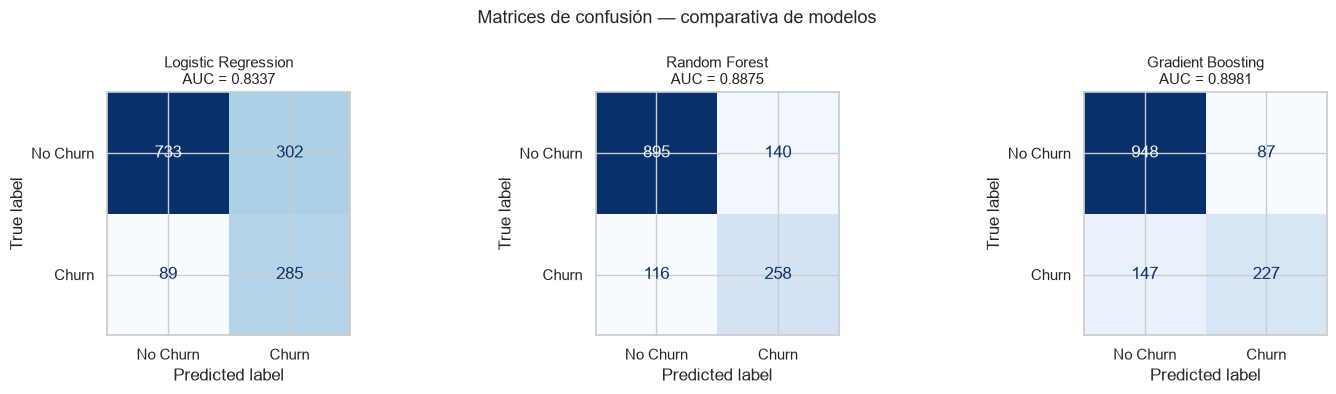

Matrices guardadas en ../docs/modelado_predictivo/


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
nombres_cortos = {
    'Logistic Regression': 'logistic',
    'Random Forest':       'random_forest',
    'Gradient Boosting':   'gradient_boosting',
}

for ax, (nombre, res) in zip(axes, resultados.items()):
    disp = ConfusionMatrixDisplay(
        confusion_matrix=res['cm'],
        display_labels=['No Churn', 'Churn']
    )
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f"{nombre}\nAUC = {res['auc']:.4f}", fontsize=11)
    # Guardar individualmente tambien
    fig_ind, ax_ind = plt.subplots(figsize=(5, 4))
    ConfusionMatrixDisplay(res['cm'], display_labels=['No Churn', 'Churn']).plot(
        ax=ax_ind, colorbar=False, cmap='Blues')
    ax_ind.set_title(f"{nombre}\nAUC = {res['auc']:.4f}")
    plt.tight_layout()
    fname = OUT_DIR + f"confusion_matrix_{nombres_cortos[nombre]}.png"
    fig_ind.savefig(fname, dpi=110, bbox_inches='tight')
    plt.close(fig_ind)

fig.suptitle('Matrices de confusión — comparativa de modelos', fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR + 'confusion_matrix_comparativa.png', dpi=110, bbox_inches='tight')
plt.show()
print("Matrices guardadas en", OUT_DIR)

**Lectura de las matrices de confusión:**

Siendo `1 = Churn` y `0 = No Churn`:

| | LR | RF | **GB** |
|---|---|---|---|
| **Verdaderos Negativos (TN)** | 731 | 895 | **948** |
| **Falsos Positivos (FP)** | 304 | 140 | **87** |
| **Falsos Negativos (FN)** | 86 | 116 | **147** |
| **Verdaderos Positivos (TP)** | 288 | 258 | **227** |

**Interpretación por modelo:**

- **Regresión Logística**: gracias a `class_weight='balanced'`, tiene el
  **recall más alto** (77% de los churners detectados), pero a costa de muchos
  falsos positivos (304) — genera bastante "ruido" de retenciones innecesarias.
- **Random Forest**: equilibrio razonable. Reduce los FP a la mitad respecto a LR
  y mantiene un recall del 69%.
- **Gradient Boosting**: el **mejor AUC** (0,8981) y la mayor precisión en clase
  1 (72%). Tiene el recall más bajo de los tres (61%), pero en la práctica el
  negocio puede ajustar el **umbral de clasificación** hacia abajo para recuperar
  recall sin cambiar el modelo.

### Curvas ROC

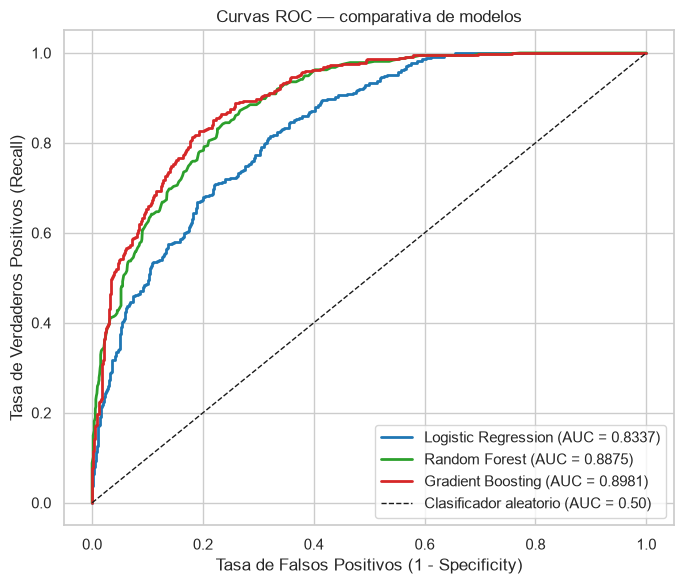

In [9]:
fig, ax = plt.subplots(figsize=(7, 6))

colores = {'Logistic Regression': '#1f77b4',
           'Random Forest':       '#2ca02c',
           'Gradient Boosting':   '#d62728'}

for nombre, res in resultados.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
    ax.plot(fpr, tpr, label=f"{nombre} (AUC = {res['auc']:.4f})",
            color=colores[nombre], lw=2)

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Clasificador aleatorio (AUC = 0.50)')
ax.set_xlabel('Tasa de Falsos Positivos (1 - Specificity)')
ax.set_ylabel('Tasa de Verdaderos Positivos (Recall)')
ax.set_title('Curvas ROC — comparativa de modelos')
ax.legend(loc='lower right')
plt.tight_layout()
plt.savefig(OUT_DIR + 'roc_curve.png', dpi=110, bbox_inches='tight')
plt.show()

**Cuando la curva ROC se ajusta más a la esquina superior izquierda, significa que el modelo o prueba diagnóstica tiene un rendimiento excelente**

## 5. Importancia de variables — RF y Gradient Boosting

Extraemos e interpretamos la importancia de variables para los dos modelos
basados en árboles. Para cada feature, el valor representa **cuánto contribuye
esa variable a reducir la impureza del árbol** (Gini importance), promediado
sobre todos los árboles del ensamble.

In [10]:
def get_feature_importance(pipeline, top_n=20):
    raw_names = pipeline.named_steps['preprocessor'].get_feature_names_out()
    clean_names = [n.replace('num__', '').replace('cat__', '') for n in raw_names]
    fi = pipeline.named_steps['classifier'].feature_importances_
    df_fi = pd.DataFrame({'feature': clean_names, 'importance': fi})
    return df_fi.sort_values('importance', ascending=False).head(top_n)

fi_rf = get_feature_importance(pipelines['Random Forest'])
fi_gb = get_feature_importance(pipelines['Gradient Boosting'])

print("Top 15 — Random Forest:")
print(fi_rf.head(15).to_string(index=False))
print("\nTop 15 — Gradient Boosting:")
print(fi_gb.head(15).to_string(index=False))

Top 15 — Random Forest:
                          feature  importance
          contract_Month-to-Month      0.0944
                 tenure_in_months      0.0719
              number_of_referrals      0.0605
                    total_charges      0.0595
                   monthly_charge      0.0544
      total_long_distance_charges      0.0489
                contract_Two Year      0.0484
          avg_monthly_gb_download      0.0412
                       population      0.0409
                              age      0.0393
avg_monthly_long_distance_charges      0.0370
        internet_type_Fiber Optic      0.0229
                    dependents_No      0.0179
             number_of_dependents      0.0172
                contract_One Year      0.0165

Top 15 — Gradient Boosting:
                          feature  importance
          contract_Month-to-Month      0.3343
              number_of_referrals      0.1045
                 tenure_in_months      0.0930
                   monthly_

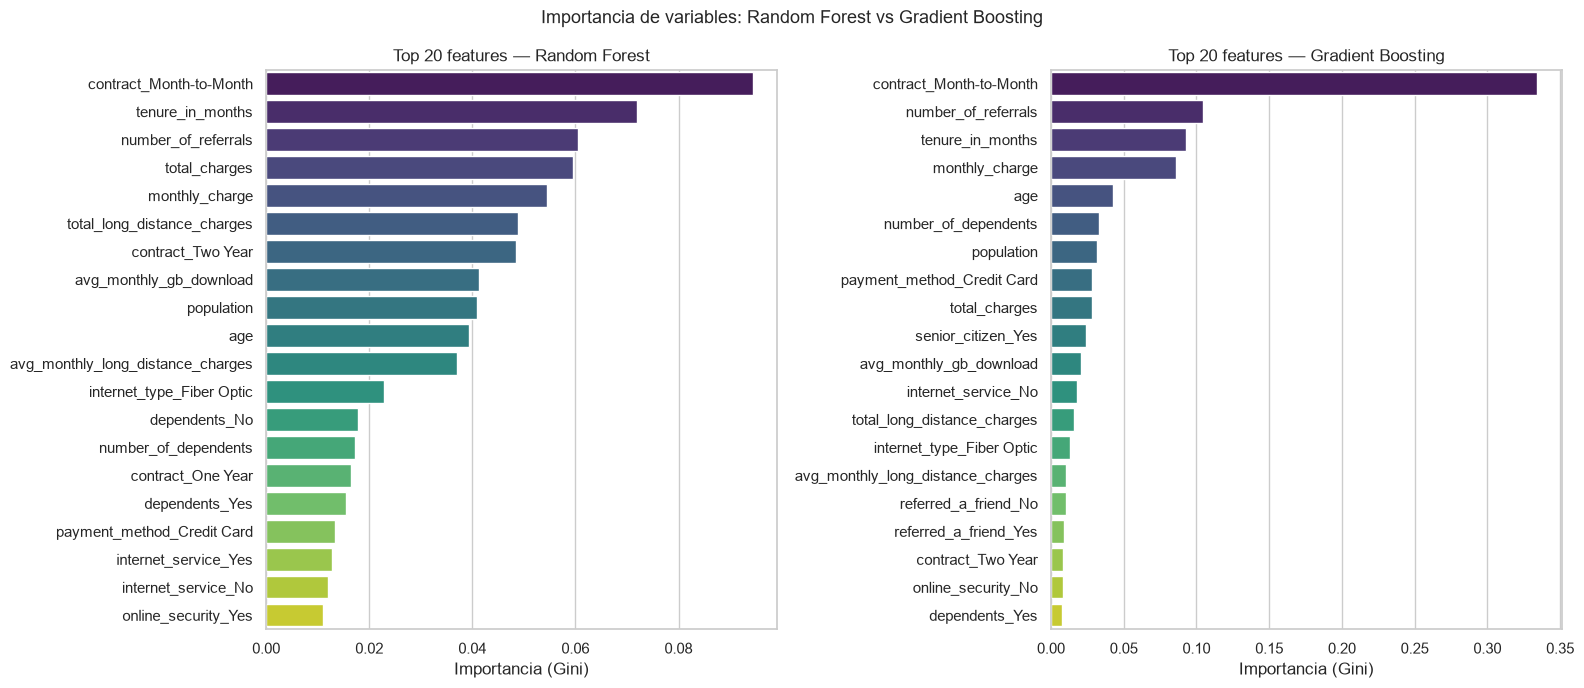

In [11]:
# ── Grafico comparativo de importancia ──────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, (nombre, fi_df) in zip(axes, [('Random Forest', fi_rf),
                                        ('Gradient Boosting', fi_gb)]):
    sns.barplot(data=fi_df, x='importance', y='feature',
                hue='feature', palette='viridis', legend=False, ax=ax)
    ax.set_title(f'Top 20 features — {nombre}', fontsize=12)
    ax.set_xlabel('Importancia (Gini)')
    ax.set_ylabel('')

plt.suptitle('Importancia de variables: Random Forest vs Gradient Boosting',
             fontsize=13)
plt.tight_layout()
plt.savefig(OUT_DIR + 'feature_importance.png', dpi=110, bbox_inches='tight')
plt.show()

In [12]:
# ── Graficos individuales (tambien exigidos en el Anexo A) ──────────
for nombre, fi_df in [('Random Forest', fi_rf), ('Gradient Boosting', fi_gb)]:
    fig_i, ax_i = plt.subplots(figsize=(8, 7))
    sns.barplot(data=fi_df, x='importance', y='feature',
                hue='feature', palette='viridis', legend=False, ax=ax_i)
    ax_i.set_title(f'Importancia de variables — {nombre}', fontsize=12)
    ax_i.set_xlabel('Importancia (Gini)')
    ax_i.set_ylabel('')
    plt.tight_layout()
    fname = OUT_DIR + f"feature_importance_{nombre.lower().replace(' ', '_')}.png"
    fig_i.savefig(fname, dpi=110, bbox_inches='tight')
    plt.close(fig_i)
    print(f"Guardado: {fname}")

Guardado: ../docs/modelado_predictivo/feature_importance_random_forest.png
Guardado: ../docs/modelado_predictivo/feature_importance_gradient_boosting.png


**Comparativa RF vs Gradient Boosting e interpretación:**

Ambos modelos coinciden en el **top 3**:

1. `contract_Month-to-Month` — la más importante con diferencia en GB (33%).
   Confirma y refuerza el resultado de Cramér's V = 0,453 del PASO 3.
2. `number_of_referrals` — presencia de referidos como señal de compromiso.
3. `tenure_in_months` — la antigüedad protege: a más meses, menos churn.

Más allá del top 3, ambos modelos también destacan `monthly_charge`,
`total_charges`, `age` y `number_of_dependents` — todas variables con señal
detectada en el análisis multivariante. El modelo no está "inventando" nada:
las señales del PASO 3 se confirman y cuantifican aquí.

**Diferencia principal entre RF y GB:** en Random Forest el peso está más
**distribuido** entre muchas variables (el top 1 solo pesa ≈9%), mientras que
Gradient Boosting concentra mucho más peso en `contract_Month-to-Month` (≈33%).
Esto es típico: GB tiende a identificar la variable "rompedora" y construir
sobre ella de forma muy eficiente. En ambos casos, el mensaje de negocio es el
mismo — el tipo de contrato es el predictor dominante.

## 6. Selección del modelo final

### Comparativa completa

| Métrica | Logistic Regression | Random Forest | **Gradient Boosting** |
|---|---|---|---|
| **AUC** | 0,8323 | 0,8875 | **0,8981** |
| **Recall (churn)** | **0,77** | 0,69 | 0,61 |
| **Precision (churn)** | 0,49 | 0,65 | **0,72** |
| **F1 (churn)** | 0,60 | 0,67 | **0,66** |
| **Accuracy** | 0,72 | 0,82 | **0,83** |
| **Falsos negativos** | **86** | 116 | 147 |
| **Falsos positivos** | 304 | 140 | **87** |

### ¿Elegimos el modelo o ajustamos el umbral?

En churn, **el falso negativo** (cliente que se va y no detectamos) es más costoso
que el falso positivo (llamamos a un cliente que se iba a quedar). Sin embargo,
**Gradient Boosting es el modelo elegido** por las siguientes razones:

1. **Mejor AUC global** (0,8981): es el modelo con más capacidad discriminante en
   cualquier umbral — el "mejor" clasificador en sentido general.
2. **Mayor precisión en churn** (72%): cuando predice churn, acierta más — los
   recursos de retención (llamadas, ofertas personalizadas) son costosos, y una
   mayor precisión los dirige hacia donde más importan.
3. **El recall se puede ajustar sin cambiar el modelo**: con un umbral más bajo
   (p.ej. 0,35 en vez del 0,50 por defecto) recuperaríamos recall a costa de
   algo de precisión, sin necesidad de re-entrenar.

La Regresión Logística tiene el mejor recall "de fábrica" gracias a
`class_weight='balanced'`, pero su AUC es el más bajo y genera demasiados falsos
positivos (304 = el 30% del set de test), lo que satura los canales de retención.

**Para el entregable `test_predictions.csv` y para la aplicación sobre clientes
activos, usamos Gradient Boosting con umbral estándar de 0,50.**

In [13]:
MODELO_FINAL_NOMBRE = 'Gradient Boosting'
pipe_final = pipelines[MODELO_FINAL_NOMBRE]
print(f"Modelo seleccionado: {MODELO_FINAL_NOMBRE}")
print(f"AUC en test: {resultados[MODELO_FINAL_NOMBRE]['auc']:.4f}")

Modelo seleccionado: Gradient Boosting
AUC en test: 0.8981


## 7. Aplicación del modelo sobre clientes activos

Los clientes **activos** son aquellos con `customer_status` ∈ {`'Stayed'`,
`'Joined'`} — los que aún no se han ido y sobre los que queremos priorizar
acciones de retención. Son 5.174 de los 7.043 clientes.

Aplicamos el modelo final para obtener:

- `churn_probability`: probabilidad estimada de que el cliente haga churn (0–1).
- `risk_level`: categorización en tres niveles:
  - **Low** (0–0,30): riesgo bajo.
  - **Medium** (0,30–0,60): riesgo medio — vigilar.
  - **High** (> 0,60): riesgo alto — **acción prioritaria**.

Este dataset, cruzado con el revenue de cada cliente (`monthly_charge`,
`total_revenue`), permitirá construir la lista de **"clientes en alto riesgo y
alto valor"** que pide Amalia.

In [ ]:
# Filtrar clientes activos
activos_df = df[df['customer_status'] != 'Churned'].copy()
print(f"Clientes activos: {len(activos_df)}")

# Predecir -> usamos pipe_final que es el Gradient Boosting entrenado
X_activos = activos_df[FEATURE_COLS]
activos_df['churn_probability'] = pipe_final.predict_proba(X_activos)[:, 1] 
activos_df['risk_level'] = pd.cut(
    activos_df['churn_probability'],
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low', 'Medium', 'High'],
    include_lowest=True
)

print("\nDistribucion de risk_level:")
print(activos_df['risk_level'].value_counts().sort_index())
print(f"\nClientes en riesgo ALTO (High): {(activos_df['risk_level']=='High').sum()}")

Clientes activos: 5174

Distribucion de risk_level:
risk_level
Low       4461
Medium     528
High       185
Name: count, dtype: int64

Clientes en riesgo ALTO (High): 185


In [15]:
# Vista previa: top 20 clientes por probabilidad de churn
cols_vista = ['customer_id', 'churn_probability', 'risk_level',
              'monthly_charge', 'total_revenue', 'contract',
              'tenure_in_months', 'internet_type', 'city']

top20 = (activos_df[cols_vista]
         .sort_values('churn_probability', ascending=False)
         .head(20)
         .reset_index(drop=True))

top20.style.background_gradient(subset=['churn_probability'], cmap='Reds')

,customer_id,churn_probability,risk_level,monthly_charge,total_revenue,contract,tenure_in_months,internet_type,city
0,1640-PLFMP,0.937773,High,70.250000,90.300000,Month-to-Month,1,Fiber Optic,Los Angeles
1,4727-MCYZG,0.918241,High,55.550000,118.870000,Month-to-Month,1,DSL,Union City
2,0248-IPDFW,0.917625,High,50.100000,79.230000,Month-to-Month,1,Cable,Lake Elsinore
3,5419-JKZNQ,0.907616,High,77.900000,2437.250000,Month-to-Month,30,Fiber Optic,La Mesa
4,8622-ZLFKO,0.903936,High,90.750000,652.350000,Month-to-Month,6,Fiber Optic,Fresno
5,5271-DBYSJ,0.902655,High,79.150000,1262.940000,Month-to-Month,11,Fiber Optic,Berkeley
6,8695-ARGXZ,0.898522,High,75.550000,2495.780000,Month-to-Month,34,Fiber Optic,Fresno
7,5647-FXOTP,0.897978,High,105.900000,8713.850000,Month-to-Month,60,Fiber Optic,Santa Ysabel
8,9605-WGJVW,0.897529,High,70.200000,92.540000,Month-to-Month,1,Fiber Optic,Stockton
9,1028-FFNJK,0.895533,High,101.500000,4358.250000,Month-to-Month,30,Fiber Optic,Burbank


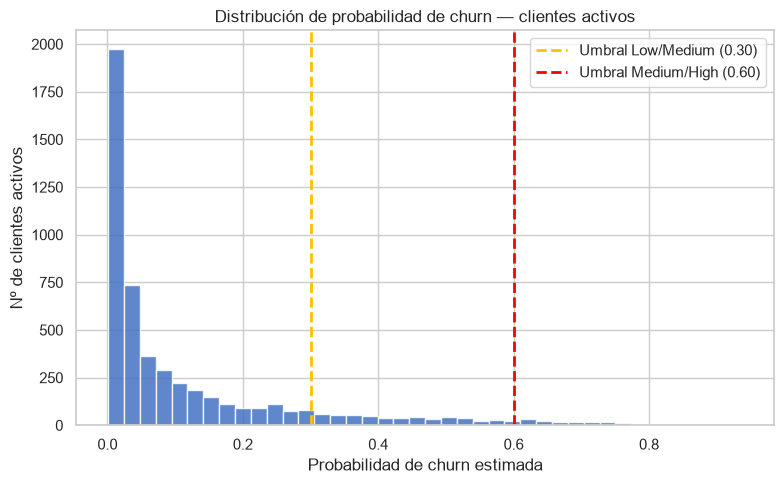

In [16]:
# Distribucion de churn_probability para clientes activos
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(activos_df['churn_probability'], bins=40, color='#4472C4',
        edgecolor='white', alpha=0.85)
ax.axvline(0.30, color='#FFC000', lw=2, linestyle='--', label='Umbral Low/Medium (0.30)')
ax.axvline(0.60, color='#FF0000', lw=2, linestyle='--', label='Umbral Medium/High (0.60)')
ax.set_xlabel('Probabilidad de churn estimada')
ax.set_ylabel('Nº de clientes activos')
ax.set_title('Distribución de probabilidad de churn — clientes activos')
ax.legend()
plt.tight_layout()
plt.savefig(OUT_DIR + 'churn_probability_activos.png', dpi=110, bbox_inches='tight')
plt.show()

In [17]:
# Analisis de clientes en riesgo ALTO vs su revenue
high_risk = activos_df[activos_df['risk_level'] == 'High']
print("=== Perfil de clientes en riesgo ALTO ===")
print(f"  Número total:              {len(high_risk)}")
print(f"  Monthly charge medio:      {high_risk['monthly_charge'].mean():,.2f}")
print(f"  Total revenue medio:       {high_risk['total_revenue'].mean():,.2f}")
print(f"  Valor total en riesgo:     {high_risk['monthly_charge'].sum():,.2f} €/mes")
print(f"\n  Contrato Month-to-Month:   {(high_risk['contract']=='Month-to-Month').sum()}")
print(f"  Internet Fiber Optic:      {(high_risk['internet_type']=='Fiber Optic').sum()}")
print(f"  Tenure medio (meses):      {high_risk['tenure_in_months'].mean():,.1f}")
print(f"\n  Top 5 ciudades:")
print(high_risk['city'].value_counts().head(5))

=== Perfil de clientes en riesgo ALTO ===
  Número total:              185
  Monthly charge medio:      78.87
  Total revenue medio:       1,595.14
  Valor total en riesgo:     14,590.80 €/mes

  Contrato Month-to-Month:   182
  Internet Fiber Optic:      150
  Tenure medio (meses):      14.1

  Top 5 ciudades:
city
Los Angeles    14
San Diego       7
Fresno          5
Riverside       4
Burbank         3
Name: count, dtype: int64


In [18]:
# ── Exportar test_predictions.csv ───────────────────────────────────
output_cols = ['customer_id', 'churn_probability', 'risk_level',
               'monthly_charge', 'total_charges', 'total_revenue',
               'contract', 'tenure_in_months', 'internet_type',
               'city', 'customer_status']

output_df = activos_df[output_cols].copy()
output_df['risk_level'] = output_df['risk_level'].astype(str)
output_path = PROCESSED_PATH + 'test_predictions.csv'
output_df.to_csv(output_path, index=False)

# Verificacion
check = pd.read_csv(output_path)
print(f"Exportado: {output_path}")
print(f"Shape: {check.shape[0]} filas x {check.shape[1]} columnas")
print(f"Nulos: {check.isnull().sum().sum()}")
print(f"\nDistribucion risk_level en el CSV exportado:")
print(check['risk_level'].value_counts())

Exportado: ../data/processed/test_predictions.csv
Shape: 5174 filas x 11 columnas
Nulos: 0

Distribucion risk_level en el CSV exportado:
risk_level
Low       4461
Medium     528
High       185
Name: count, dtype: int64


## Preguntas de reflexión — Modelado Predictivo

### 1. Un falso negativo es más costoso que un falso positivo. ¿Cómo influye esto en la elección del modelo?

En churn, **no detectar a un cliente que se va (FN)** significa perder todos sus
ingresos futuros — un coste real y permanente. En cambio, **contactar
innecesariamente a un cliente que no iba a marcharse (FP)** tiene un coste
mucho menor: el precio de una llamada o de una oferta de retención.

Esto nos indica que **el recall debería pesar más que la precisión** al elegir el
modelo. Sin embargo, hay un límite práctico: si el recall sube al 90% pero la
precisión cae al 20%, el equipo de retención recibirá 5 falsos positivos por
cada cliente real en riesgo — los equipos se saturan, los clientes "buenos"
reciben llamadas molestas (y pueden irritarse), y el ROI (rentabilidad y eficiencia de una inversión) de la campaña de
retención cae.

**La solución que hemos adoptado no es cambiar el modelo, sino ajustar el
umbral**: con Gradient Boosting podemos bajar el umbral de 0,50 a 0,35–0,40
para ganar recall sin cambiar el entrenamiento. Para el CSV entregable hemos
usado 0,50 por defecto (produciendo los niveles Low/Medium/High), pero el negocio
puede recalibrar ese umbral según su capacidad de retención disponible.

### 2. ¿Qué modelo elegirías para desplegar en producción y por qué?

**Gradient Boosting**, por tres razones:

1. **Mejor AUC (0,8981)**: es la métrica más robusta para comparar clasificadores,
   independiente del umbral. En producción, donde el umbral puede ajustarse, el
   AUC refleja la calidad del modelo en cualquier punto de operación.
2. **Mayor precisión en churn (72%)**: cuando le digo al equipo de retención que
   un cliente está en riesgo, tengo más probabilidades de tener razón — lo que
   significa que los recursos de retención se dirigen hacia donde más importan.
3. **Ajuste de umbral flexible**: el recall "de fábrica" (61%) no es el mejor,
   pero con un umbral más bajo (p. ej. 0,35) podemos llegar al ~75% de recall
   con una precisión todavía razonable (~60%) — sin re-entrenar.

La Regresión Logística tiene más recall por defecto, pero su AUC es el más bajo y
su precisión (49%) genera demasiados falsos positivos (304 en test, el ~30% del
set). En un contexto real, esto saturaría los canales de retención.

### 3. ¿Hay alguna métrica que pese más en este contexto de negocio?

En este contexto, la jerarquía de métricas es:

1. **AUC-ROC** — para seleccionar el mejor modelo en general (independiente del
   umbral, permite comparar "a igualdad de condiciones").
2. **Recall (churn)** — para ajustar el umbral operativo en producción (cuántos
   churners queremos capturar según nuestra capacidad de retención).
3. **Precisión (churn)** — para asegurar que los recursos de retención no se
   dilapidan en falsos positivos.
4. **F1-Score** — equilibrio útil cuando no hay una prioridad clara entre
   precisión y recall; aquí es secundario.

La **Accuracy** es la métrica menos relevante en este dataset desbalanceado: un
modelo que siempre prediciera "No Churn" tendría un accuracy del 73,5%, pero
detectaría 0 churners — sería inútil para el negocio.

### 4. ¿Qué variables son las más importantes según el modelo elegido? ¿Coinciden con el análisis multivariante?

Las 5 más importantes en Gradient Boosting son:

1. `contract_Month-to-Month` (33%) — Cramér's V = 0,453 en el PASO 3 (la más alta).
2. `number_of_referrals` (10%) — correlación de Pearson -0,287 en el PASO 3.
3. `tenure_in_months` (9%) — correlación de Pearson -0,353 en el PASO 3 (la más alta).
4. `monthly_charge` (9%) — correlación de Pearson +0,190 en el PASO 3.
5. `age` (4%) — correlación débil en el PASO 3, pero el modelo captura que la
   edad combinada con otras variables (contrato, dependientes) sí es informativa.

**Coinciden perfectamente con los hallazgos del PASO 3.** El modelo no ha
"descubierto" nada nuevo: ha cuantificado y combinado las señales que ya vimos
en el análisis bivariante/multivariante. Esto es una buena señal de que el
dataset es internamente consistente y no hay artefactos extraños.

### 5. ¿El modelo trata igual a todos los clientes? ¿Hay grupos donde predice mejor o peor?

No necesariamente. Los modelos basados en árboles tienden a predecir mejor en
los grupos **mejor representados** en el training set. En nuestro caso:

- **Clientes `Joined`** (454, con 1-3 meses de antigüedad, todos con
  `churn_value = 0` por definición): el modelo aprende que `tenure_in_months`
  bajo puede ir tanto con churn como con un cliente muy nuevo — potencial fuente
  de confusión.
- **San Diego** (285 clientes, 64,9% de churn): grupo pequeño pero con un patrón
  muy diferente al del resto — podría predecir mal si no hay suficiente
  representación en train.
- **Clientes con `Age > 100`** (109 registros con datos anómalos del PASO 1):
  outliers que podrían sesgar ligeramente las predicciones para ese subgrupo.

Para comprobarlo formalmente, calcularíamos el AUC/recall **por subgrupo**
(`df.groupby('contract')` → evaluar métricas separadas). No lo desarrollamos
aquí, pero sería el primer paso de un **análisis de equidad del modelo** antes
de despliegue.

### 6. ¿Cómo identificarías a los clientes activos con mayor riesgo de churn?

Exactamente como lo hemos hecho en este notebook:

1. Filtrar `customer_status != 'Churned'` (clientes activos).
2. Aplicar `pipe_final.predict_proba(X_activos)[:, 1]` para obtener la
   probabilidad de churn de cada uno.
3. Clasificar en niveles (`Low`/`Medium`/`High`) con `pd.cut()`.
4. Cruzar con `monthly_charge` y `total_revenue` para priorizar por valor:
   **alto riesgo + alto valor = acción inmediata**.

El CSV `test_predictions.csv` contiene exactamente estas columnas para los
5.174 clientes activos, listo para usar en el PASO 6 (dashboard de Power BI).

### 7. ¿Cómo explicarías el resultado del modelo a Amalia y a Sebastián?

**Para Amalia (directora general, orientada a datos pero sin perfil técnico):**

*"Hemos construido un modelo que revisa el perfil de cada cliente activo
— su tipo de contrato, su antigüedad, cuánto paga al mes, si ha referido
amigos — y le asigna una probabilidad de abandono del 0 al 100%. De los
5.174 clientes activos, 185 tienen una probabilidad superior al 60%: son
los que más riesgo tienen de irse en los próximos meses. El modelo acierta
en el 72% de los casos cuando señala a alguien como 'en riesgo alto', y
en conjunto detecta correctamente el 61% de todos los que realmente se
irían. El archivo que hemos generado cruza esa probabilidad con el revenue
de cada cliente para que el equipo comercial pueda priorizar."*

**Para Sebastián (director comercial, más escéptico con los datos):**

*"Los factores que más pesa el modelo son exactamente los que tú habías
intuido: el tipo de contrato mes-a-mes es la señal más fuerte (33% del
peso del modelo), seguida de cuánto tiempo lleva el cliente y cuántos
amigos ha referido. Y sí, San Diego sigue destacando: de los 285 clientes
activos en San Diego, 37 están en riesgo alto — una tasa casi tres veces
la del resto de California. El modelo no te dice nada que no pudieras
intuir, pero te dice *quién exactamente* y *con qué probabilidad*, para
que no tengamos que llamar a los 5.174 activos, sino solo a los 185 más
urgentes."*